In [43]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gput

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from re import X
import numpy as np
import pandas as pd
import networkx as nx
import itertools
from math import factorial
from networkx.algorithms.community import louvain_communities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold, train_test_split
from node2vec import Node2Vec
from infomap import Infomap
import graph_tool.all as gt
import joblib
from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBClassifier
import optuna
from scipy import stats


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [37]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

def k_fold_cross_validation_exp(G_train, folds_data, features_list=None, n_trials=50, graph_name="G_NAME"):
    study = gput._run_optuna_tuning(folds_data, features_list, n_trials=n_trials)
    
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            results.append({
                'Trial': trial.number,
                'Avg_AUC': trial.value,
                'Std_AUC': trial.user_attrs.get('std_auc'),
                'Avg_AP': trial.user_attrs.get('avg_ap'),
                'Delta_AUC': trial.user_attrs.get('delta_auc'),
                'Params': trial.params
            })
    
    summary_df = pd.DataFrame(results).sort_values(by='Avg_AUC', ascending=False)

    print("\n" + "="*80)
    print(f"{'RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS':^80}")
    print("="*80)

    cols = ['Trial', 'Avg_AUC', 'Std_AUC', 'Avg_AP', 'Delta_AUC']
    print(summary_df[summary_df['Trial'] == 0][cols].to_string(index=False))
    print("-" * 80)
    print(summary_df.head(10)[cols].to_string(index=False))
    print("="*80)

    save_dir = "outputs/results"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"optuna_results_{graph_name}.csv"
    full_path = os.path.join(save_dir, filename)
    summary_df.to_csv(full_path, index=False)
    print(f"Résultats sauvegardés dans : {full_path}")

    best_params = study.best_params.copy()
    best_params.update({'tree_method': 'hist', 'n_estimators': 150})
    
    return best_params, summary_df

### 1.1 Execution des expériences

In [39]:
features_GT_proba = ['GT_proba']
features_GT_sbm = ['GT_sbm_density', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v']
features_GT_pos = ['GT_pos_dist', 'GT_degrees_spatial_u','GT_degrees_spatial_v', 'GT_spatial_deg_product', 
                   #'GT_spatial_gravity_log'
                  ]
features_structure = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_commu_surprise = ["surprise_density", "same_surprise"]
features_commu_infomap = ['infomap_density', 'same_infomap']
features_commu_sbm = ['sbm_density', 'same_sbm']
features_embeddings = ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]

experiments = {
    "GT_absolue (proba)": features_GT_proba,
    "GT_sbm": features_GT_sbm,
    "GT_pos": features_GT_pos,
    #"GT": features_GT_sbm + features_GT_pos,
    "Structure_Only": features_structure,
    "Embeddings_Only": features_embeddings,
    "Inferred_Commu only": features_commu_inferee,
    #"Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    #"Structure + Inferred_Commu": features_structure + features_commu_inferee,
    #"Structure + Embeddings": features_structure + features_embeddings,
    "Full_features": features_structure + features_commu_inferee + features_embeddings
}

all_results = []

#for i in [0.00,1.00]:
for i in np.arange(1.00, -0.25, -0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    G_name_obj = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    G = load_graphml_safe(f"graph_library/{G_name_obj}.graphml")

    if 'GroundTruth_JSON' in G.graph:
        print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
        gt_raw = json.loads(G.graph['GroundTruth_JSON'])
        
        GT = {'GT_sbm_matrix': np.array(gt_raw['GT_sbm_matrix']),
            'GT_pos': np.array(gt_raw['GT_pos']),
            'GT_sbm_id': np.array(gt_raw['GT_sbm_id']),
            'GT_degrees_sbm': np.array(gt_raw['GT_degrees_sbm']),
            'GT_degrees_spatial': np.array(gt_raw['GT_degrees_spatial'])
             }
        
        if 'P_matrix_JSON' in G.graph:
            print("P_matrix trouvée.")
            GT['GT_proba'] = np.array(json.loads(G.graph['P_matrix_JSON']))
    else:
        print("[WARNING] Aucune GroundTruth_JSON trouvée dans G.graph")
        GT = None

    pre_calculated_folds = gput._prepare_precalculated_folds(G_train, k=1, GroundTruth=GT)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            print(set(dataset_train.columns))
            continue

        print(f" Running: {exp_name} for SBM={i}")
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=30)
        
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train, features=feat_list,
                                                                          parameters = Params, plot=False)

        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 5 Feature Importance pour {exp_name} :")
        print(feat_imp_series.head(5).to_string())

        probs = model.predict_proba(X_test)[:, 1]
        preds = model.predict(X_test)

        if exp_name == "GT_sbm":
            model_GT, X_test_GT_only, y_test_GT_only, probs_GT, preds_GT_only = model, X_test, y_test, probs, preds
        elif exp_name == "Inferred_Commu only":
            model_s, X_test_s, y_test_s, probs_s, preds_s = model, X_test, y_test, probs, preds
            
        # Évaluation sur le dataset de référence FIXE (Graphe SBM 1.0)
        # On force l'ordre des colonnes de eval_dataset pour correspondre au modèle
        X_eval_fixed = dataset_eval[feat_list] 
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, dataset_eval["target"], "EXP_")
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC-ROC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC-ROC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Top_Feature": feat_imp_series.index[0], # On stocke la #1 pour analyse
            "Top_Importance": feat_imp_series.iloc[0]
        })

# Recap final
df_compare = pd.DataFrame(all_results)

print("\n" + "="*50)
print("RÉCAPITULATIF DES EXPÉRIENCES (SBM vs Ground Truth)")
print("="*50)

# On affiche sans l'index pour plus de clarté si tu as déjà une colonne 'exp_name'
print(df_compare.to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

print("="*50 + "\n")

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_shuffled_v5_20260401.csv")
df_compare.to_csv(output_path, index=False)
print(f" Succès ! Fichier sauvegardé dans : {output_path}")

SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00.
✅ Graphe chargé : 198 nœuds et 2533 liens.
[INIT] Extraction de la GT GroundTruth pour artificial_graph_sbmv5_1_00_pos_0_00...
P_matrix trouvée.
[K-FOLD] Préparation séquentielle de 1 folds...
--- Démarrage Parallèle Fold 1 ---
Graphe original: 1549 liens
Graphe d'entraînement: 1316 liens
Liens cachés pour le test: 233

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality, Katz

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...
Calcul des communautés via leiden...
Calcul des communautés via surprise...
Calcul des communautés via significance...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 10): 100%|██████████| 9/9 [00:00<00:00, 17.49it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.35s
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 24.83it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.28s
Calcul des embeddings via crosswalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


...

Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.31s
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 22.11it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.75s
Calcul des embeddings via crosswalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 22.66it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.46s
Préparation des listes de paires...
Extraction parallèle sur 2761 paires (n_jobs=10)...
Injection de la Ground Truth (6 sources)...
DataFrame enrichi. Colonnes GT : ['GT_sbm_density', 'GT_pos_dist', 'GT_degrees_spatial_u', 'GT_degrees_spatial_v', 'GT_spatial_deg_product', 'GT_sbm_id_u', 'GT_sbm_id_v', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v', 'GT_proba']
DataFrame créé avec succès : 2761 lignes.
Préparation des listes de paires...
Extraction parallèle sur 10868 paires (n_jobs=10)...
Injection de la Ground Truth (6 sources)...
DataFrame enrichi. Colonnes GT : ['GT_sbm_density', 'GT_pos_dist', 'GT_degrees_spatial_u', 'GT_degrees_spatial_v', 'GT_spatial_deg_product', 'GT_sbm_id_u', 'GT_sbm_id_v', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v', 'GT_proba']
DataFrame créé avec succès : 10868 lignes.
 Running: GT_absolue (proba) for SBM=0.0

               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  S

### 1.2 Plot des performances des expériences en fonction de SBM_ratio

Graphique sauvegardé ici : outputs/plots/artificial_graphs_shuffled_v5_20260401_AUC-ROC_eval_per_SBM_ratio.png


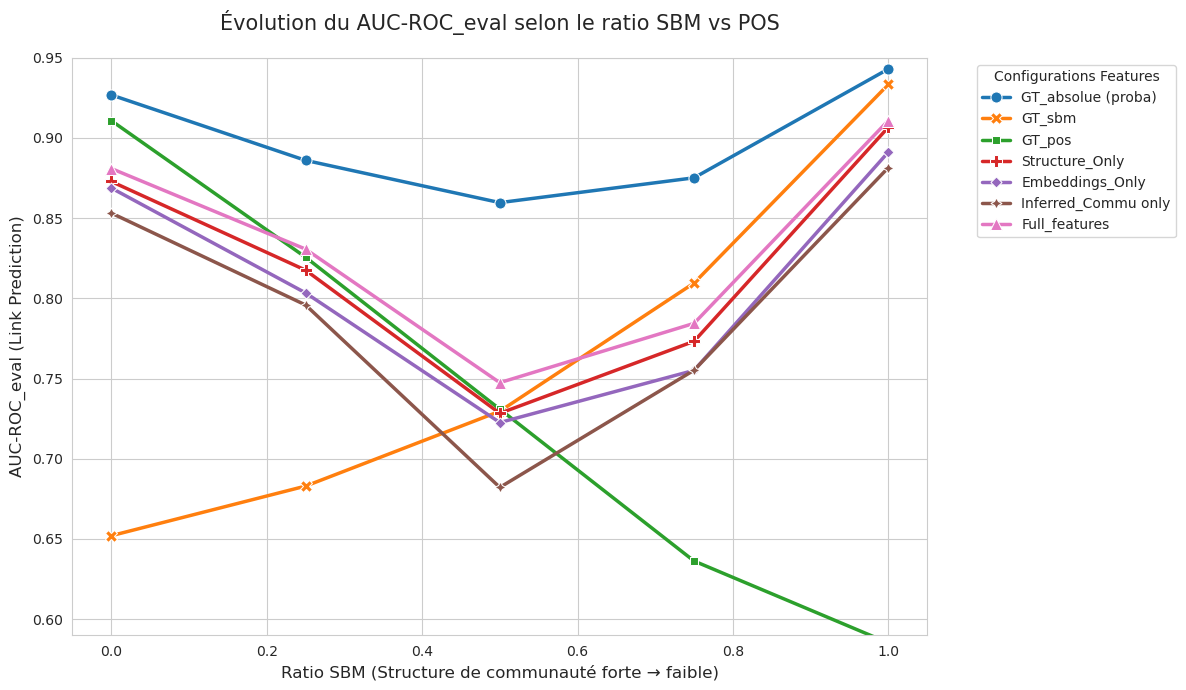

In [40]:
def plot_f1_comparison(df_results, metric="F1-Score", name ="OUBLI"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Ratio_SBM", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le ratio SBM vs POS", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.59, 0.95) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{name}_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

df_compare = pd.read_csv("outputs/results/comparaison_finale_structure_shuffled_v5_20260401.csv")

plot_f1_comparison(df_compare, metric="AUC-ROC_eval", name = "artificial_graphs_shuffled_v5_20260401" )

### 1.3 Analyse détaillée des faux positifs, vrais pos, etc ...

In [ ]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

### 1.4 plots des AP curves

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

### 1.5 Analyse de variance de probas prédites

In [ ]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)

### 1.5 Analyse des communautés inférées

In [ ]:
def compute_agreement_ratio(X_test, dataset, algo_col='same_infomap'):
    """
    Calcule le pourcentage de paires où l'inférence est d'accord avec la GT.
    """
    # 1. On récupère la vérité terrain
    y_true = dataset.loc[X_test.index, 'same_block_reel']
    y_inf  = X_test[algo_col]
    
    # 2. On compare
    agreement = (y_true == y_inf).mean()
    
    print(f"Ratio d'accord entre {algo_col} et la réalité : {agreement:.2%}")
    
    # Détail pour ton chercheur :
    # Combien de fois l'algorithme a vu une communauté là où il n'y en a pas (Faux Positifs de structure)
    over_detection = ((y_inf == 1) & (y_true == 0)).sum()
    print(f"  └─ Paires vues 'ensemble' par erreur : {over_detection}")
    
    return agreement

def count_inferred_communities(dataset, algo_prefix='infomap'):
    """
    Compte le nombre de clusters uniques trouvés par un algorithme.
    Ex: algo_prefix='infomap' ira chercher 'infomap_u' et 'infomap_v'.
    """
    col_u = f"{algo_prefix}_u"
    col_v = f"{algo_prefix}_v"
    
    if col_u in X_test.columns and col_v in X_test.columns:
        # On combine les deux colonnes et on compte les valeurs uniques
        all_commus = pd.concat([X_test[col_u], X_test[col_v]])
        n_unique = all_commus.nunique()
        print(f"Nombre de communautés uniques ({algo_prefix}) : {n_unique}")
        return n_unique
    else:
        print(f"Colonnes pour {algo_prefix} introuvables.")
        return None

# Utilisation
n_infomap = count_inferred_communities(dataset, 'infomap')
ratio = compute_agreement_ratio(X_test_s, dataset, 'same_infomap')

### 1.6 Exploration visuelle des positions et catégories

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

In [ ]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.7 Analyse de corrélation entre features et GT

In [61]:
features_GT = ['GT_sbm_density', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v',
               'GT_pos_dist', 'GT_degrees_spatial_u','GT_degrees_spatial_v', 'GT_spatial_deg_product']
features_structure = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_embeddings = ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]
all_matrices = {}
results_corr = []

for i in np.arange(0.00, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)

    #features_to_test = [c for c in dataset_eval.columns if c not in features_GT and c not in ['u', 'v', 'target', 'label']]
    features_to_test = features_structure
    
    current_corr = dataset_eval[features_to_test + features_GT].corr(method='spearman')
    sub_matrix = current_corr.loc[features_to_test, features_GT]
    all_matrices[i] = sub_matrix

    #print(f"\n--- Matrice de Corrélation GT pour Alpha = {i} ---")
    print(sub_matrix.round(3))

    for f in features_to_test:
        for gt in features_GT:
            results_corr.append({
                'alpha': i,
                'feature': f,
                'gt_feature': gt,
                'correlation': current_corr.loc[f, gt]
            })

df_evolution = pd.DataFrame(results_corr)

SHAP Analysis introuvable pour artificial_graph_sbmv5_0_00_pos_1_00.
        GT_sbm_density  GT_degrees_sbm_u  GT_degrees_sbm_v  GT_pos_dist  \
pr_u            -0.028            -0.113             0.006        0.052   
pr_v            -0.047             0.009            -0.116        0.060   
ppr_u           -0.029            -0.121             0.007        0.058   
ppr_v           -0.049             0.009            -0.123        0.066   
lcc_u            0.008             0.017            -0.006        0.117   
lcc_v            0.010            -0.014             0.002        0.112   
and_u            0.014            -0.006            -0.007       -0.035   
and_v            0.008            -0.017            -0.030       -0.033   
dc_u            -0.027            -0.110             0.006        0.049   
dc_v            -0.047             0.009            -0.115        0.058   
katz_u          -0.027            -0.107             0.005        0.045   
katz_v          -0.046         

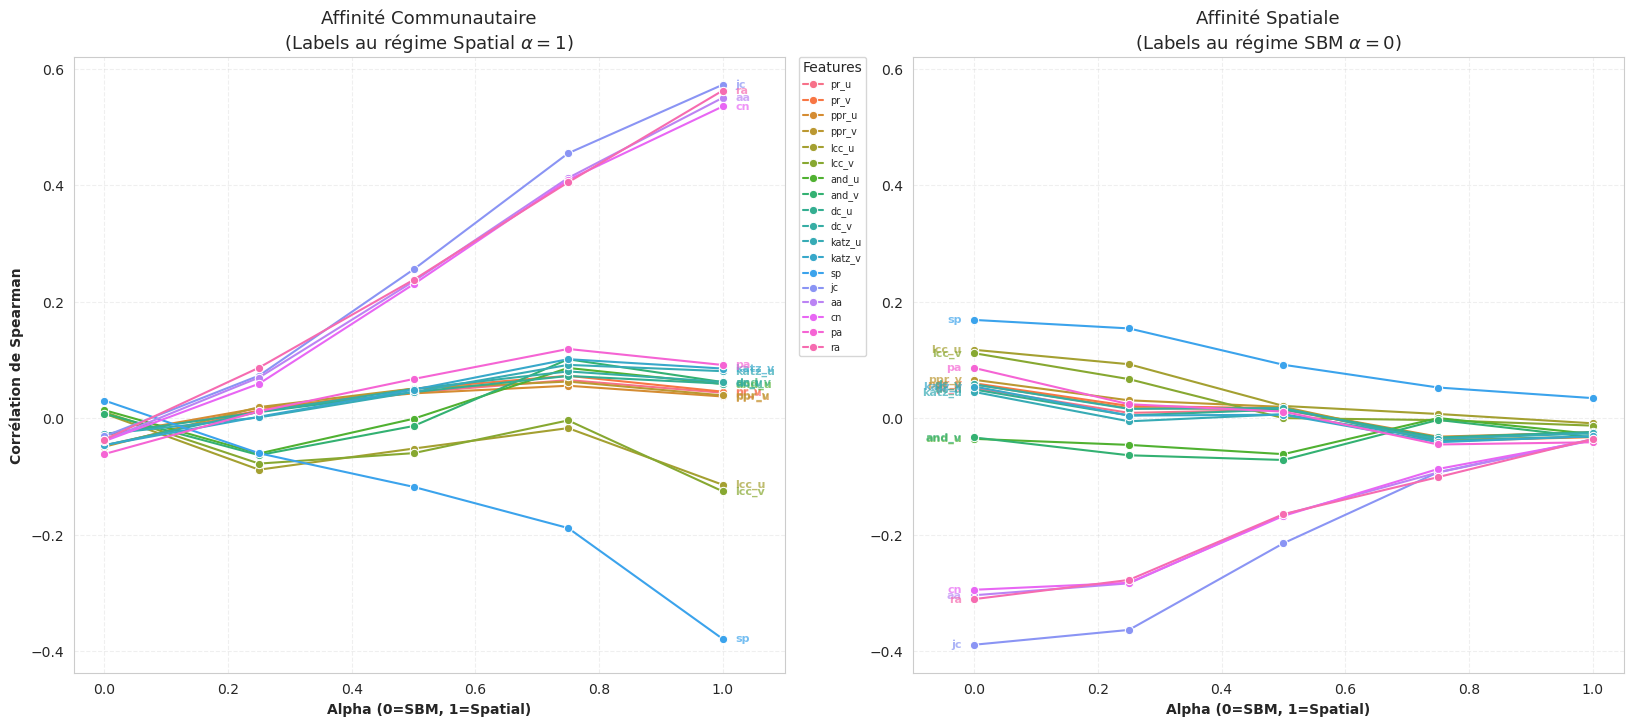

In [62]:
gt_commu = 'GT_sbm_density'
gt_spatial = 'GT_pos_dist'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

def add_labels_inverted(ax, data, hue_col, x_target, alignment='left'):
    lines = ax.get_lines()
    features = data[hue_col].unique()
    for i, feature in enumerate(features):
        subset = data[data[hue_col] == feature]
        idx = (subset['alpha'] - x_target).abs().idxmin()
        point = subset.loc[idx]
        color = lines[i].get_color()
        offset = 0.02 if alignment == 'left' else -0.02
        ax.text(point['alpha'] + offset, point['correlation'], feature, fontsize=8, va='center', ha=alignment, color=color, fontweight='bold', alpha=0.7)

# --- Plot 1 : SBM (Labels à DROITE @ alpha=1.0) ---
data_commu = df_evolution[df_evolution['gt_feature'] == gt_commu]
sns.lineplot(data=data_commu, x='alpha', y='correlation', hue='feature', marker='o', ax=ax1)
ax1.set_title(f"Affinité Communautaire\n(Labels au régime Spatial $\\alpha=1$)", fontsize=13)
add_labels_inverted(ax1, data_commu, 'feature', x_target=1.0, alignment='left')
ax1.set_xlim(-0.05, 1.1) 
ax1.legend(title="Features", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='x-small', borderaxespad=0.)

# --- Plot 2 : Spatial (Labels à GAUCHE @ alpha=0.0) ---
data_spatial = df_evolution[df_evolution['gt_feature'] == gt_spatial]
sns.lineplot(data=data_spatial, x='alpha', y='correlation', hue='feature', marker='o', ax=ax2, legend=False)
ax2.set_title(f"Affinité Spatiale\n(Labels au régime SBM $\\alpha=0$)", fontsize=13)
add_labels_inverted(ax2, data_spatial, 'feature', x_target=0.0, alignment='right')
ax2.set_xlim(-0.1, 1.05)

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel("Alpha (0=SBM, 1=Spatial)", fontweight='bold')
    ax.set_ylabel("Corrélation de Spearman", fontweight='bold')
    ax2.tick_params(labelleft=True)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    
plt.subplots_adjust(wspace=0.18) 
plt.show()

### 1.8 - Analyse de transférabilité

In [ ]:
features_GT_sbm = ['GT_sbm_density', 'same_GT_sbm']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_commu_surprise = ["surprise_density", "same_surprise"]

experiments = {
    "GT_sbm": features_GT_sbm,
    "Inferred_Commu only": features_commu_inferee,
    "Surprise_mothafucka": features_commu_surprise
 }

trained_models = {} 
all_transfer_results = []

G_source = f"artificial_graph_sbmv4_1_00_pos_0_00"
graphs_tests = ["artificial_graph_sbmv4_bis_1_00_pos_0_00",
                "artificial_graph_sbmv4_ter_1_00_pos_0_00",
                "artificial_graph_sbmv4_quad_1_00_pos_0_00"
               ]

print(f"\n--- PHASE 1 : Entrainement des modèles sur le graphe Source ---")
G_train_src , dataset_train_src, dataset_eval_src, _, _, _ = gp.load_all_data_for_graph(G_source)

pre_calculated_folds = gput._prepare_precalculated_folds(G_train_src, k=1)

for exp_name, feat_list in experiments.items():
    missing = set(feat_list) - set(dataset_train_src.columns)
    if missing:
        print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
        print(set(dataset_train_src.columns))
        continue

    print(f" Running: {exp_name}")
    Params, summary_optim = k_fold_cross_validation_exp(G_train_src, pre_calculated_folds, feat_list, n_trials=30)
    
    stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train_src, features=feat_list,
                                                                      parameters = Params, plot=False)

    X_src = dataset_eval_src[feat_list]
    y_src = dataset_eval_src["target"]

    stats_transfer = gp.get_performance_metrics(model, X_src, y_src, "TRANSFER_")
    importances = model.feature_importances_
    top_feat = feat_list[np.argmax(importances)]

    all_transfer_results.append({
            "Graph_name" : "GRAPH SOURCE",
            "Experiment": exp_name,
            "AUC_Transfer": stats_transfer["TRANSFER_AUC-ROC"].iloc[0],
            "AP_Transfer": stats_transfer["TRANSFER_AP"].iloc[0],
            "Top_Feature": top_feat
        })

    trained_models[exp_name] = {"model": model, "features": feat_list}


print(f"\n--- PHASE 2 : Test de transférabilité sur tous les graphes ---")
for target_graph_name in graphs_tests :
    print(f" Inférence sur : {target_graph_name}")
    try:
        _, _, dataset_eval_target, _, _, _ = gp.load_all_data_for_graph(target_graph_name)
    except:
        print(f" Graphe {target_graph_name} introuvable. Skip.")
        continue

    for exp_name, model_data in trained_models.items():
        model = model_data["model"]
        feat_list = model_data["features"]
        
        if not set(feat_list).issubset(dataset_eval_target.columns):
            continue

        X_target = dataset_eval_target[feat_list]
        y_target = dataset_eval_target["target"]
        
        stats_transfer = gp.get_performance_metrics(model, X_target, y_target, "TRANSFER_")
        
        importances = model.feature_importances_
        top_feat = feat_list[np.argmax(importances)]

        all_transfer_results.append({
            "Graph_name" : target_graph_name,
            "Experiment": exp_name,
            "AUC_Transfer": stats_transfer["TRANSFER_AUC-ROC"].iloc[0],
            "AP_Transfer": stats_transfer["TRANSFER_AP"].iloc[0],
            "Top_Feature": top_feat
        })

# --- RÉCAPITULATIF ET ANALYSE ---
df_transfer = pd.DataFrame(all_transfer_results)
print("\n" + "="*60)
print("RÉSULTATS DE TRANSFÉRABILITÉ (Modèle Source -> Graphes Cibles)")
print("="*60)
pivot_results = df_transfer.pivot(index="Graph_name", columns="Experiment", values="AUC_Transfer")
print(pivot_results.to_string(float_format=lambda x: "{:,.4f}".format(x)))

In [ ]:
plot_f1_comparison(df_transfer, metric="AUC_Transfer")

## 2 - Exploration des Shap values

### 2.1 - Concaténation des Shap_Values pour toutes les valeurs de ratio_sbm

In [10]:
all_summaries = []

for i in np.arange(0, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    print(f"Type de l'objet : {type(shap_explainer)}")
    print(f"Dimensions des valeurs : {shap_explainer.values.shape}")

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)


SHAP Analysis introuvable pour artificial_graph_sbmv5_0_00_pos_1_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (550, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv5_0_25_pos_0_75.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (558, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv5_0_50_pos_0_50.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (536, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv5_0_75_pos_0_25.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (518, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (522, 50)


### 2.2 - Plot des shap_values par sbm_ratio et par feature

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio_v4_mean_abs_shap.png


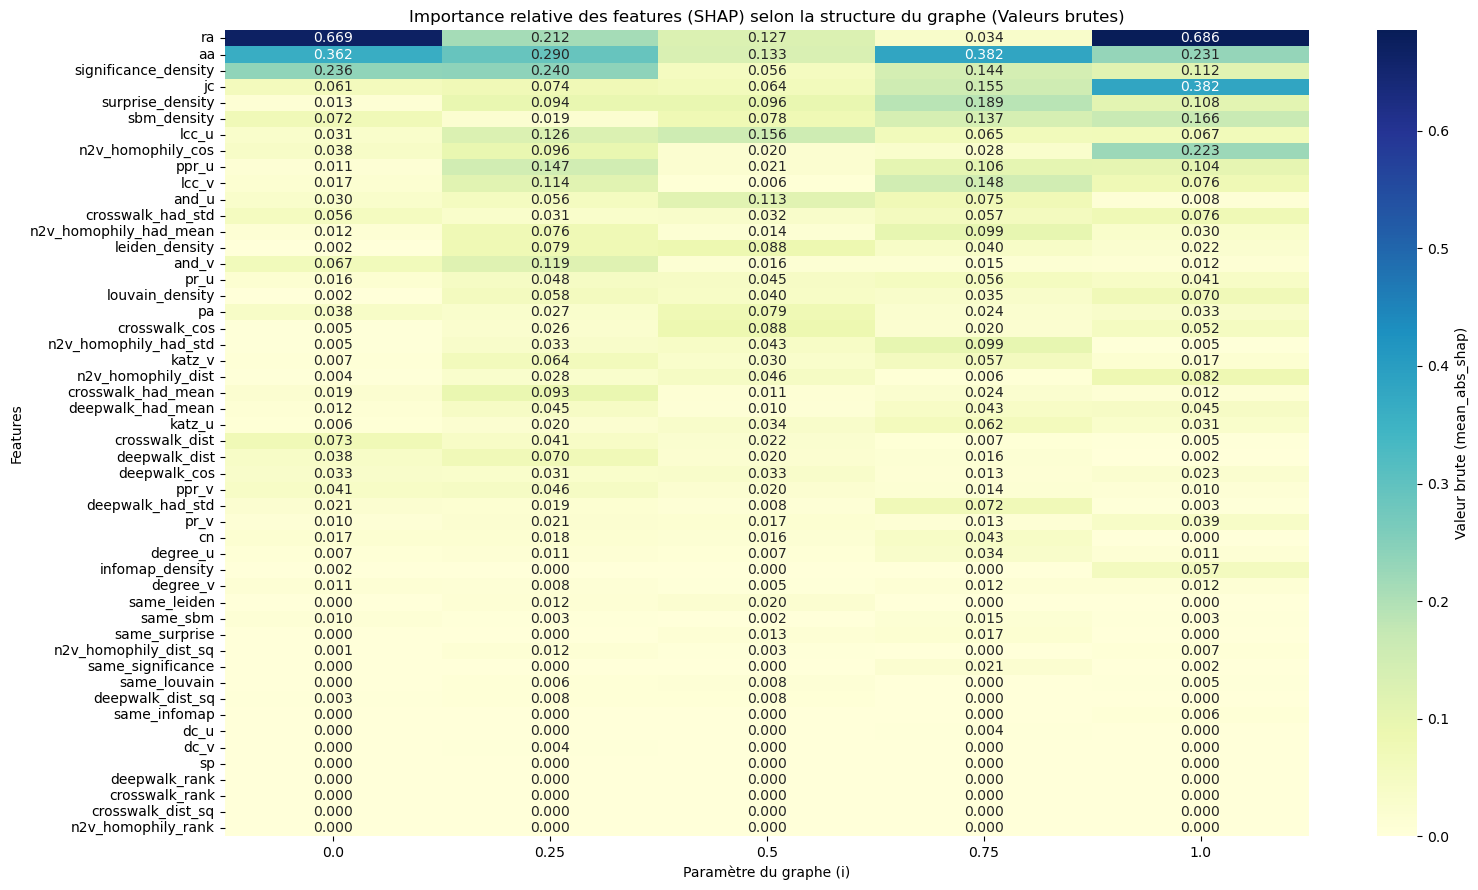

Index(['feature', 'mean_shap', 'mean_abs_shap', 'sbm_param'], dtype='object')
cn, aa, ra, jc, pa, sp, degree_u, degree_v, pr_u, pr_v, ppr_u, ppr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, katz_u, katz_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, leiden_density, same_leiden, surprise_density, same_surprise, significance_density, same_significance, n2v_homophily_cos, n2v_homophily_dist, n2v_homophily_dist_sq, n2v_homophily_had_mean, n2v_homophily_had_std, deepwalk_cos, deepwalk_dist, deepwalk_dist_sq, deepwalk_had_mean, deepwalk_had_std, crosswalk_cos, crosswalk_dist, crosswalk_dist_sq, crosswalk_had_mean, crosswalk_had_std, n2v_homophily_rank, deepwalk_rank, crosswalk_rank, cn, aa, ra, jc, pa, sp, degree_u, degree_v, pr_u, pr_v, ppr_u, ppr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, katz_u, katz_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, leiden_density, same_leiden, surprise_density, same_surprise, si

'\nall_distribs = []\nfor i in np.arange(0, 1.05, 0.05):\n    sbm_val = f"{i:.2f}"\n    pos_val = f"{1-i:.2f}"\n    G_name = f"artificial_graph_sbm_{sbm_val.replace(\'.\', \'_\')}_pos_{pos_val.replace(\'.\', \'_\')}"\n    \n    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)\n    X_test = xgboost_data[\'X_test\']\n    y_test = xgboost_data[\'y_test\']\n    \n    pos_sp = X_test[y_test == 1][\'sp\'].value_counts(normalize=True).to_dict()\n    neg_sp = X_test[y_test == 0][\'sp\'].value_counts(normalize=True).to_dict()\n    \n    row = {\'sbm_param\': round(i, 2)}\n    for dist in range(1, 7):\n        row[f\'pos_sp_{dist}\'] = pos_sp.get(dist, 0)\n        row[f\'neg_sp_{dist}\'] = neg_sp.get(dist, 0)\n    \n    row[\'pos_sp_7+\'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)\n    row[\'neg_sp_7+\'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)\n    \n    all_distribs.append(row)\n\ndf_sp_detailed = pd.DataFrame(all_distribs)\n\ncols = [\'sbm_param\'] +

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, annot=True, fmt=fmt_type, cmap="YlGnBu", yticklabels=True, cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio_v4_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_shapvals_concat, metric="mean_abs_shap", as_ratio=False)
print(df_shapvals_concat.columns)
features_list = df_shapvals_concat['feature']
print(", ".join(map(str, features_list)))

"""
all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))
"""

### 2.3 - Exploration du ranking des SHAP vals des features sur chaque paire (voir si qq métriques on avg pas ouf perfs fort sur qq paires) 

In [ ]:
def plot_feature_importance_heatmap(df_results, output_filename="heatmap_shap_percentage_presence_top_k.png"):
    """
    Génère une heatmap dynamique selon le ratio présent dans le DataFrame.
    """
    ratio_col = [c for c in df_results.columns if '_ratio' in c][0]
    k_val = ratio_col.replace('top', '').replace('_ratio', '')

    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=ratio_col)
    
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt=".1%", 
                cmap="YlGnBu", 
                cbar_kws={'label': f'% de présence au Top {k_val} (SHAP)'})

    plt.title(f"Évolution de la dominance des features (Top {k_val})")
    plt.xlabel("Paramètre SBM (i)")
    plt.ylabel("Features")
    
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig(f"outputs/plots/{output_filename}", dpi=300, bbox_inches='tight')
    plt.show()


results_list = []
k_target = 3 

for i in np.arange(0, 1.05, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    try:
        _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        vals = shap_explainer.values
        if isinstance(vals, list): vals = vals[1]

        df_ranks = gp.calculate_feature_rankings(vals, xgboost_data['X_test'].columns, top_k=k_target, plot=False)
        
        top_k_sum = df_ranks.iloc[0:k_target, :].sum(axis=0)
        
        for feat_name, val in top_k_sum.items():
            results_list.append({
                'sbm_param': i,
                'feature': feat_name,
                f'top{k_target}_ratio': val / 100  
            })
            
    except Exception as e:
        print(f"Skipping {G_name} due to error: {e}")

df_shap_rankings = pd.DataFrame(results_list)

plot_feature_importance_heatmap(df_shap_rankings)

### 2.4 - Explo locale des shap values par catégorie & corrélations

In [62]:
def plot_Dominance_Index_VS_probas(explainability_dataset):
    plt.figure(figsize=(10, 2))
    
    sns.regplot(
        data=explainability_dataset,
        x="Dominance_probas_Index",
        y="Dominance_Index",
        scatter_kws={'alpha':0.3, 's':10},
        line_kws={'color':'red'}
    )
    
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.axvline(0, color='black', linewidth=1, linestyle='--')
    
    plt.title("Alignement : Dominance des Probabilités vs Dominance SHAP")
    plt.xlabel("Lien (<0: Spatial | >0: SBM)")
    plt.ylabel("<0: Embeddings | >0: Commu")
    plt.grid(alpha=0.3)
    plt.show()

def test_Mann_Whitney(explainability_dataset) :
    rho, p_val_rho = stats.spearmanr(explainability_dataset["Dominance_probas_Index"], 
                                     explainability_dataset["Dominance_Index"])
    
    group_spatial = explainability_dataset[explainability_dataset["Dominance_probas_Index"] < 0]["Dominance_Index"]
    group_sbm = explainability_dataset[explainability_dataset["Dominance_probas_Index"] > 0]["Dominance_Index"]
    
    # 3. Test de significativité (Mann-Whitney U car les distributions ne sont sûrement pas normales, se base sur les rangs)
    u_stat, p_val_test = stats.mannwhitneyu(group_spatial, group_sbm)
    
    print(f"=== ANALYSE STATISTIQUE ===")
    print(f"Corrélation de Spearman : {rho:.4f} (p-value: {p_val_rho:.2e})")
    print(f"Moyenne Dominance SHAP (Groupe Spatial) : {group_spatial.mean():.4f}")
    print(f"Moyenne Dominance SHAP (Groupe SBM)     : {group_sbm.mean():.4f}")
    print(f"Différence significative (Mann-Whitney) : {'OUI' if p_val_test < 0.05 else 'NON'} (p={p_val_test:.2e})")

SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00.


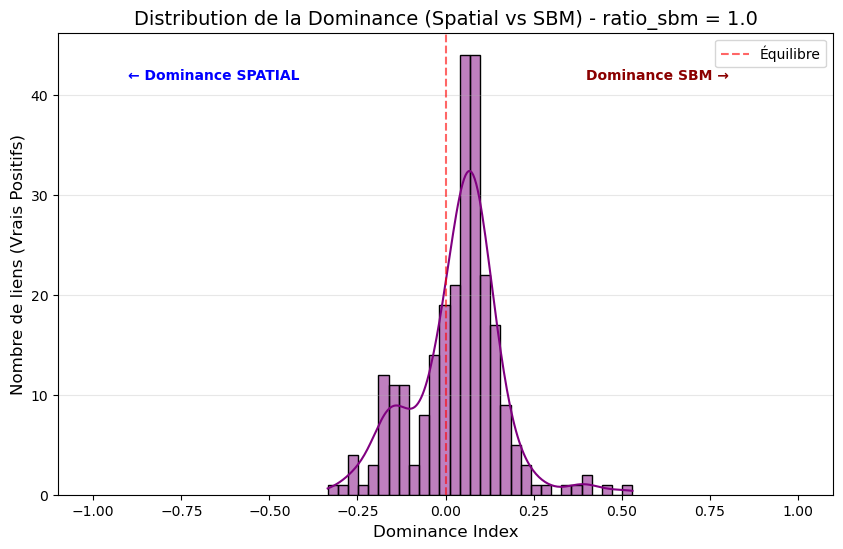

SHAP Analysis introuvable pour artificial_graph_sbmv5_0_75_pos_0_25.


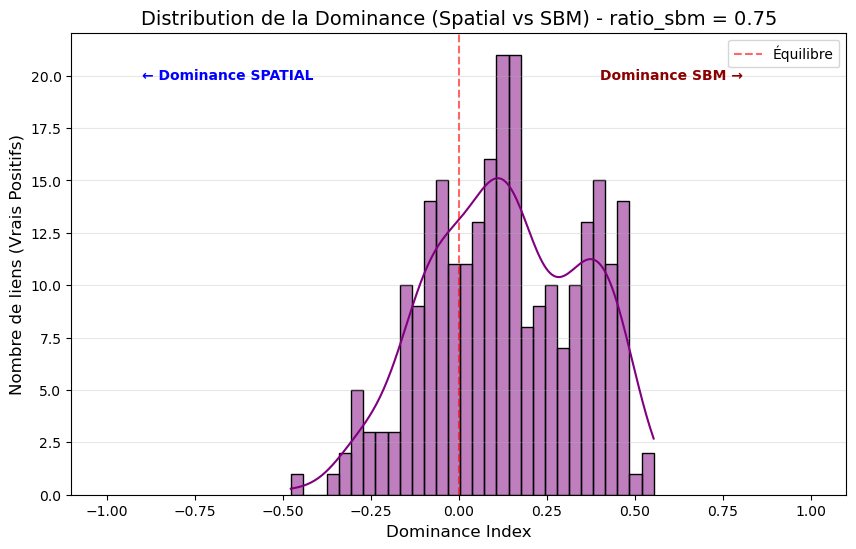

SHAP Analysis introuvable pour artificial_graph_sbmv5_0_50_pos_0_50.


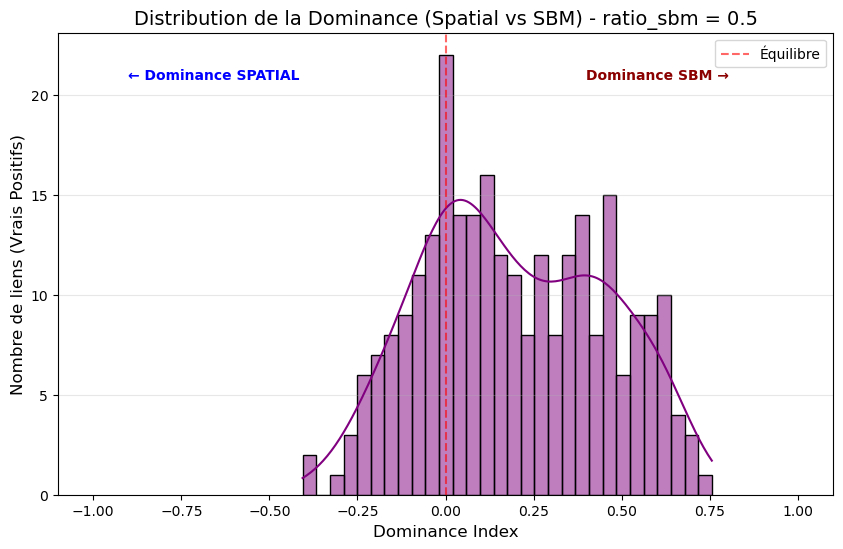

SHAP Analysis introuvable pour artificial_graph_sbmv5_0_25_pos_0_75.
logic_map.html


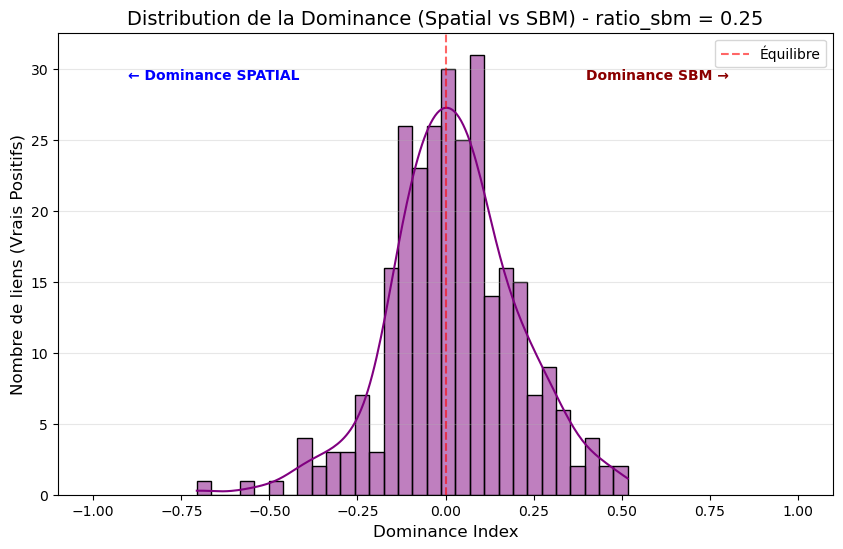

SHAP Analysis introuvable pour artificial_graph_sbmv5_0_00_pos_1_00.


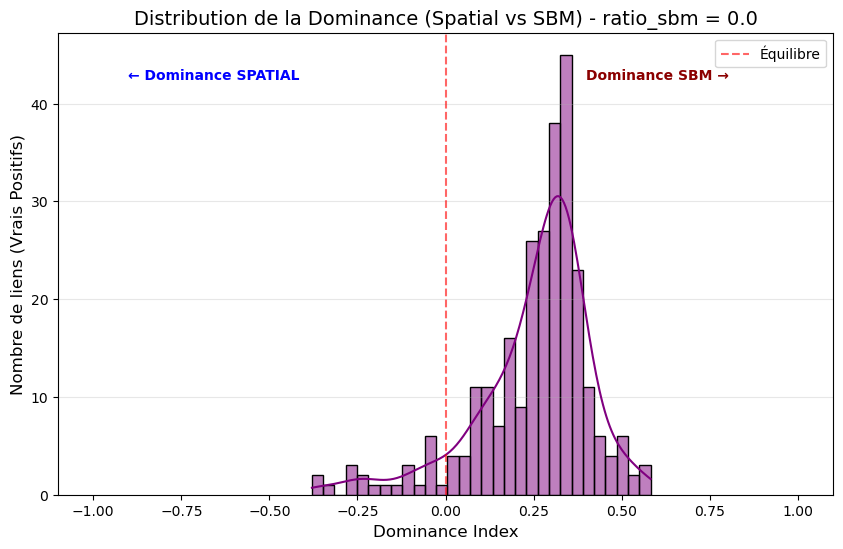


=== TABLEAU RÉCAPITULATIF DES CORRÉLATIONS ===
 ratio_sbm  Com_sbm  Com_pos  Com_hyb  Emb_sbm  Emb_pos  Emb_hyb  Str_sbm  Str_pos  Str_hyb
      1.00   0.2172  -0.0804   0.2172   0.2406   0.0884   0.2406   0.7687   0.1150   0.7687
      0.75   0.4509  -0.1140   0.4482   0.0945  -0.1957   0.0417   0.7037  -0.1517   0.7074
      0.50   0.4831  -0.2198   0.2535   0.0910   0.0759   0.1571   0.1939   0.2767   0.4420
      0.25  -0.1061   0.0927   0.0606  -0.0514   0.4189   0.4123   0.0131   0.5617   0.5794
      0.00   0.0139   0.1694   0.1694  -0.0223  -0.0453  -0.0453  -0.0355   0.7230   0.7230


In [75]:
feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"],
        "Groupe_Embeddings": ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]
    }

p_matrices = joblib.load("graph_library/artificial_graph_sbmv5_P_matrices.joblib")
correlations_recap = []

for i in np.arange(1.00, -0.25, -0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    G, _, dataset_hidden, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)

    explainability_dataset = gput.build_explainability_dataset(shap_explainer, xgboost_data, dataset_hidden, feature_mapping, 
                                                               p_matrices_origin =p_matrices, ratio_sbm=i)

    explainability_dataset["Dominance_probas_Index"] = (explainability_dataset["p_uv_sbm"]-explainability_dataset["p_uv_pos"]) / (explainability_dataset["p_uv_sbm"]+explainability_dataset["p_uv_pos"])

    #print(explainability_dataset.head(2))
    if i == 0.25 :
        gput.plot_pyvis_eval_graph_map(explainability_dataset, G, G_name,  filename="logic_map.html")
    gput.plot_dominance_distribution(explainability_dataset, title = f"Distribution de la Dominance (Spatial vs SBM) - ratio_sbm = {i}")
    #plot_Dominance_Index_VS_probas(explainability_dataset)
    #test_Mann_Whitney(explainability_dataset)
    
    # --- Coefficients de Corrélation avec Dominance_idex ---
    row = {"ratio_sbm": i}
    colonnes_p = ["p_uv_sbm", "p_uv_pos", "p_uv_hyb"]
    groupes_shap = {
        "SHAP_Groupe_Communities": "Com",
        "SHAP_Groupe_Embeddings": "Emb",
        "SHAP_Groupe_Structure": "Str"
    }

    for full_name, short_name in groupes_shap.items():
        for p_col in colonnes_p:
            corr = explainability_dataset[full_name].corr(explainability_dataset[p_col], method = "pearson")
            suffix = p_col.split('_')[-1]
            col_name = f"{short_name}_{suffix}"
            row[col_name] = round(corr, 4)

    correlations_recap.append(row)

correlations_recap = pd.DataFrame(correlations_recap)

print("\n=== TABLEAU RÉCAPITULATIF DES CORRÉLATIONS ===")
print(correlations_recap.to_string(index=False))

## 3 - Exploration des features et groupes de features

### 3.1 - Correlation des features entre elles

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

RRRRRRRRRRRRATIO i : 0
Features ac 1 unique valeur pour rati_sbm=0.00 :    sbm_density  same_sbm
0     0.023002         1
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_00.png


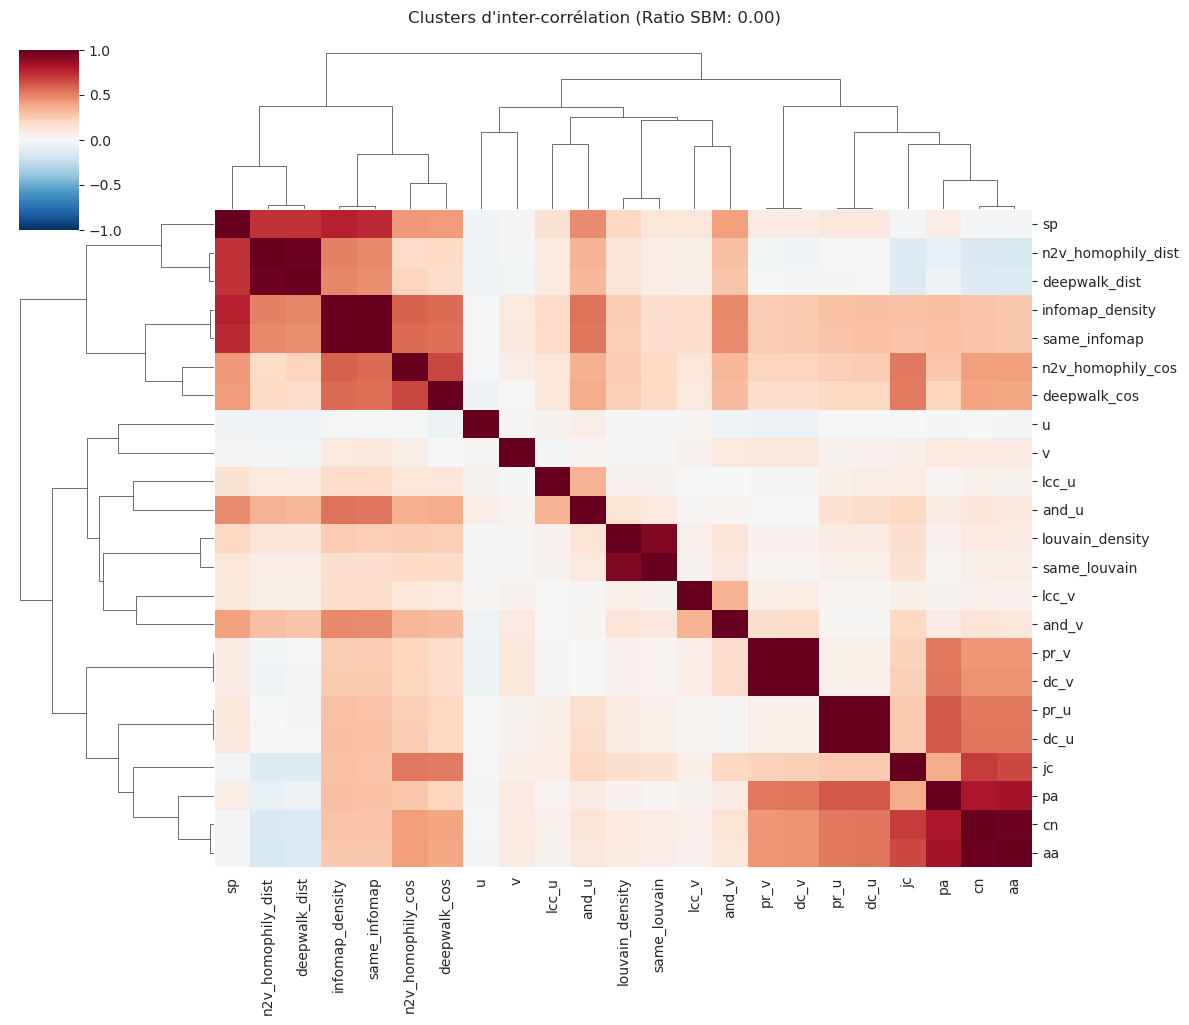

NameError: name 'hierarchy' is not defined

<Figure size 1000x500 with 0 Axes>

In [67]:
# On garde tes groupes pour l'analyse
group_mapping = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Communities": ['sbm_density', 'same_sbm', 'infomap_density', 'same_infomap',"louvain_density", "same_louvain"],
    "Groupe_Embeddings": ['n2v_homophily_cos', 'n2v_homophily_dist', 'deepwalk_cos', 'deepwalk_dist']
}

output_folder = "outputs/plots"
os.makedirs(output_folder, exist_ok=True)

ratios = [0, 0.25, 0.50, 0.75, 1.00]
for i in ratios:
    print(f"RRRRRRRRRRRRATIO i : {i}")
    sbm_val_str = f"{i:.2f}"
    pos_val_str = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val_str.replace('.', '_')}_pos_{pos_val_str.replace('.', '_')}"
    
    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)    
    features = [c for c in dataset_train.columns if c != 'target']
    df_features = dataset_train[features]

    print(f"Features ac 1 unique valeur pour rati_sbm={sbm_val_str} : {df_features.loc[:, df_features.nunique() <= 1].head(1)}")
    df_features = df_features.loc[:, df_features.nunique() > 1]

    # --- CALCUL DE LA MATRICE DE CORRÉLATION ---
    corr_matrix = df_features.corr(method='pearson')
    
    # --- PLOT 1 : CLUSTERMAP (La vue d'ensemble) ---
    # Combine la heatmap et le dendrogramme
    g = sns.clustermap(corr_matrix, 
                       method='complete', 
                       cmap='RdBu_r', 
                       vmin=-1, vmax=1,
                       figsize=(12, 10))
    g.fig.suptitle(f"Clusters d'inter-corrélation (Ratio SBM: {sbm_val_str})", y=1.02)
    
    save_path = os.path.join(output_folder, f"correlation_clustermap_sbm_{sbm_val_str.replace('.', '_')}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Graphique sauvegardé : {save_path}")

    plt.show()

    # --- PLOT 2 : DENDROGRAMME PUR (Focus structure) ---
    plt.figure(figsize=(10, 5))
    features_clean = df_features.columns.tolist()
    # Distance = 1 - valeur absolue de la corrélation
    dissimilarity = 1 - np.abs(corr_matrix)
    # Linkage sur la matrice de corrélation nettoyée
    Z = hierarchy.linkage(squareform(dissimilarity, checks=False), method='complete')
    
    hierarchy.dendrogram(Z, labels=features_clean, leaf_rotation=90, color_threshold=0.3)
    plt.axhline(y=0.3, color='r', linestyle='--', label='Seuil de forte corrélation (0.7)')
    plt.title(f"Hiérarchie des variables (Ratio SBM: {sbm_val_str})")
    plt.ylabel("Dissimilarité (1 - |corr|)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.2 - Exploration gu Gain  de chaque feature 

In [78]:
# --- 1. GÉNÉRATION DES DICTIONNAIRES D'IMPORTANCE ---
rank_dfs = {}

for i in [1.0, 0.75, 0.5, 0.25, 0.0]:
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    ratio_label = f"Ratio_SBM_{sbm_val}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    model = xgboost_data['model']
    
    # Gain du booster
    importance_gain = model.get_booster().get_score(importance_type='gain')
    
    # Création du DF
    df = pd.DataFrame(list(importance_gain.items()), columns=['Feature', 'Gain'])
    df = df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    # Calcul Rang et Poids
    df['Rank'] = df.index + 1
    df['Weight_pct'] = (df['Gain'] / df['Gain'].sum()) * 100
    
    rank_dfs[ratio_label] = df
    print(f"{ratio_label} chargé.")


if "Ratio_SBM_1.00" in rank_dfs and "Ratio_SBM_0.00" in rank_dfs:
    # 1. Préparation des données sources
    df_sbm = rank_dfs["Ratio_SBM_1.00"].copy()
    df_spa = rank_dfs["Ratio_SBM_0.00"].copy()
    
    # 2. Merge avec renommage propre
    comparison = pd.merge(
        df_sbm[['Feature', 'Rank', 'Weight_pct']], 
        df_spa[['Feature', 'Rank', 'Weight_pct']], 
        on='Feature', 
        suffixes=('_SBM', '_Spatial'), 
        how='outer'
    )
    
    # 3. Nettoyage des valeurs manquantes
    comparison['Weight_pct_SBM'] = comparison['Weight_pct_SBM'].fillna(0.0)
    comparison['Weight_pct_Spatial'] = comparison['Weight_pct_Spatial'].fillna(0.0)
    comparison['Rank_SBM'] = comparison['Rank_SBM'].fillna(99).astype(int)
    comparison['Rank_Spatial'] = comparison['Rank_Spatial'].fillna(99).astype(int)
    
    # 4. Calcul des colonnes de tri et d'analyse
    comparison['Sum_Weight'] = comparison['Weight_pct_SBM'] + comparison['Weight_pct_Spatial']
    comparison['Weight_Delta'] = comparison['Weight_pct_SBM'] - comparison['Weight_pct_Spatial']
    
    # 5. Filtrage : au moins 0.5% dans l'un des deux mondes
    mask = (comparison['Weight_pct_SBM'] >= 0.5) | (comparison['Weight_pct_Spatial'] >= 0.5)
    final_table = comparison[mask].copy()
    
    # 6. Tri par importance cumulée
    final_table = final_table.sort_values(by='Sum_Weight', ascending=False)
    
    # Affichage final
    pd.options.display.float_format = '{:.2f}'.format
    cols_to_print = [
        'Feature', 
        'Weight_pct_SBM', 'Rank_SBM', 
        'Weight_pct_Spatial', 'Rank_Spatial', 
        'Weight_Delta', 'Sum_Weight'
    ]
    
    print("Tableau des Features Significatives (Seuil > 0.5%)")
    print("-" * 100)
    print(final_table[cols_to_print].to_string(index=False))

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.
Ratio_SBM_1.00 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_75_pos_0_25.
Ratio_SBM_0.75 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_50_pos_0_50.
Ratio_SBM_0.50 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_25_pos_0_75.
Ratio_SBM_0.25 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_00_pos_1_00.
Ratio_SBM_0.00 chargé.
Tableau des Features Significatives (Seuil > 0.5%)
----------------------------------------------------------------------------------------------------
               Feature  Weight_pct_SBM  Rank_SBM  Weight_pct_Spatial  Rank_Spatial  Weight_Delta  Sum_Weight
     same_significance           12.15         1                6.88             6          5.27       19.02
                    jc            9.18         2                8.56             3          0.62       17.74
  significance_density            5.81         5             

## 4 - Other